In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("smart_farming_sensor_data.csv")

# lihat data awal
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [36]:
df.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [39]:
df.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [52]:
df = df.dropna()

In [54]:
for col in df.select_dtypes(include=['float64','int64']).columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [67]:
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

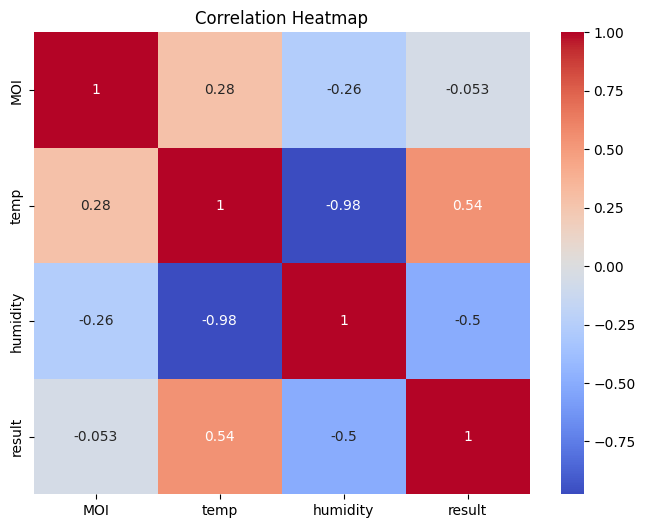

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# ambil hanya kolom numerik
numeric_df = df.select_dtypes(include=['float64','int64'])

# hitung korelasi
corr_matrix = numeric_df.corr()

# buat heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [58]:
if 'timestamp' in df.columns:
    df.set_index('timestamp').plot(figsize=(10,5))
    plt.title("Sensor Data Trend Over Time")
    plt.show()

In [59]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv berhasil disimpan")

cleaned_data.csv berhasil disimpan


In [62]:
total_cells = df.size
missing_cells = df.isnull().sum().sum()
non_null_cells = total_cells - missing_cells

In [63]:
accuracy = 1 - (missing_cells / total_cells)
accuracy

np.float64(1.0)

In [64]:
completeness = non_null_cells / total_cells
completeness

np.float64(1.0)

In [65]:
if 'timestamp' in df.columns:
    recent_data = df[df['timestamp'] >= df['timestamp'].max() - pd.Timedelta(days=30)]
    timeliness = len(recent_data) / len(df)
    timeliness
else:
    print("Kolom timestamp tidak tersedia")

Kolom timestamp tidak tersedia


In [66]:
print("Data Quality Score")
print("Accuracy:", accuracy)
print("Completeness:", completeness)

if 'timestamp' in df.columns:
    print("Timeliness:", timeliness)

Data Quality Score
Accuracy: 1.0
Completeness: 1.0
